Code for drawing graph animation

In [1]:
%matplotlib inline
from network_utilities import adjacency_matrix_to_graph
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Tuple
from IPython import display

## Code for updating a Jupyter notebook plot in realtime
## is from google AI overview from prompt
## "jupyter notebook update plot in loop"

## All code assumes nodes are consecutive integers from 0 to some max number

desired_num_vertices: int = 30

def _get_initial_positions(desired_num_vertices: int) -> Tuple[nx.Graph, dict[int, tuple[float, float]]]:
    # Put all the vertices around a circle
    A: np.array = np.zeros((desired_num_vertices,desired_num_vertices))
    G = adjacency_matrix_to_graph(A)
    pos = nx.circular_layout(G)
    return G, pos

def _configure_plot(pos: dict[int, tuple[float,float]]) -> None:
    ax = plt.gca()
    x_positions: list[float] = [x for x,_ in pos.values()]
    y_positions: list[float] = [y for _,y in pos.values()]
    ax.set_xlim(min(x_positions)-.1, max(x_positions)+.1)
    ax.set_ylim(min(y_positions)-.1, max(y_positions)+.1)
    ax.set_aspect('equal')

def _update_plot(G: nx.Graph, 
                 pos: dict[int, tuple[float, float]], 
                 vertex_set: set[int], 
                 edge_set: set[tuple[int,int]]) -> None:
    desired_node_size = 200
    G.add_edges_from(edge_set)
    nx.draw_networkx_nodes(G, pos, 
                        nodelist = list(vertex_set),
                        node_color=['lightblue'],
                        node_size=desired_node_size,
                        alpha=0.8)
    nx.draw_networkx_edges(G,pos,edgelist=list(edge_set),width=0.5)

    display.clear_output(wait=True)
    display.display(plt.gcf())
    time.sleep(0.5)


Functions for you to define

In [2]:
import random

In [3]:
def add_edges_wikipedia_version(vertex_set: set[int], 
               new_vertex: int, 
               G: nx.Graph) -> set[tuple[int,int]]:
    new_edges: set[tuple[int,int]] = set()
    total_degree = sum([G.degree(node) for node in vertex_set])
    for node in vertex_set:
        p_connect = G.degree(node) / total_degree
        if random.random() < p_connect:
            new_edges.add((node, new_vertex))
    return new_edges


In [4]:
def add_edges_networkx_version(vertex_set: set[int], 
               new_vertex: int, 
               G: nx.Graph,
               required_edges: int = 1) -> set[tuple[int,int]]:
    new_edges: set[tuple[int,int]] = set()
    if required_edges < 1:
        raise ValueError("must have at least one required edge")

    total_degree = sum([G.degree(node) for node in vertex_set])
    while len(new_edges) < required_edges:
        for node in vertex_set:
            p_connect = G.degree(node) / total_degree
            if random.random() < p_connect:
                new_edges.add((node, new_vertex))
    return new_edges


Wikipedia version

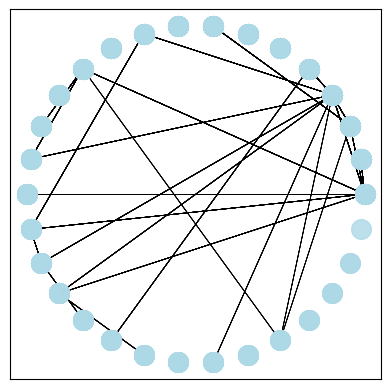

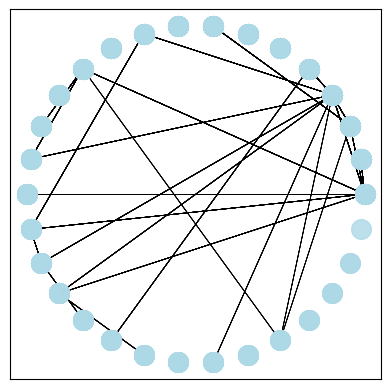

In [5]:
# Initialize drawing
G, pos = _get_initial_positions(desired_num_vertices)
_configure_plot(pos)

# m0 in the wikipedia article on Barabasi Albert network
vertex_set: set[int] = {0,1}
edge_set: set[tuple[int,int]] = {(0,1)}
degree_dict: dict[int,int] = {0:1, 1:1}

# Add edges
while len(vertex_set) <= desired_num_vertices:
    _update_plot(G, pos, vertex_set, edge_set)
    new_vertex = len(vertex_set)
    new_edges = add_edges_wikipedia_version(vertex_set, new_vertex, G)
    vertex_set.add(new_vertex)
    edge_set.update(new_edges)

In [6]:
from plotting_utilities import *

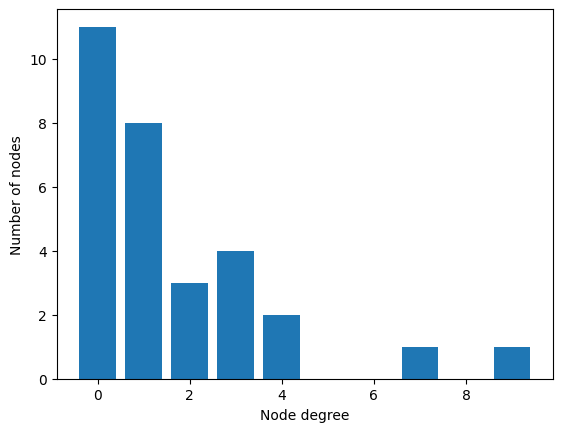

In [7]:
show_degree_distribution(G)

Networkx version

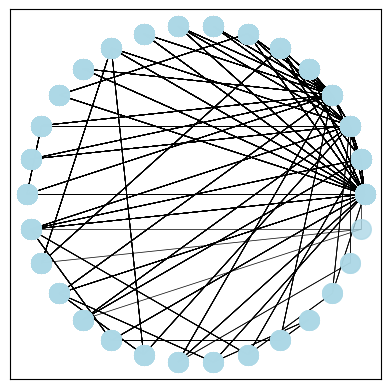

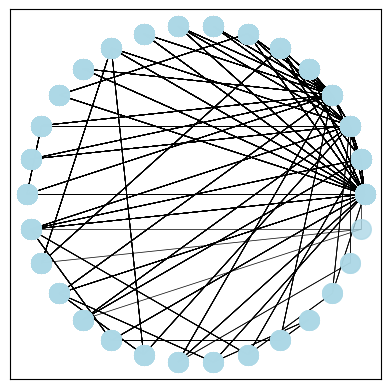

In [8]:
# Initialize drawing
G, pos = _get_initial_positions(desired_num_vertices)
_configure_plot(pos)

# m0 in the wikipedia article on Barabasi Albert network
vertex_set: set[int] = {0,1}
edge_set: set[tuple[int,int]] = {(0,1)}
degree_dict: dict[int,int] = {0:1, 1:1}

# Add edge
while len(vertex_set) <= desired_num_vertices:
    _update_plot(G, pos, vertex_set, edge_set)
    new_vertex = len(vertex_set)
    new_edges = add_edges_networkx_version(vertex_set, new_vertex, G, required_edges=2)
    vertex_set.add(new_vertex)
    edge_set.update(new_edges)

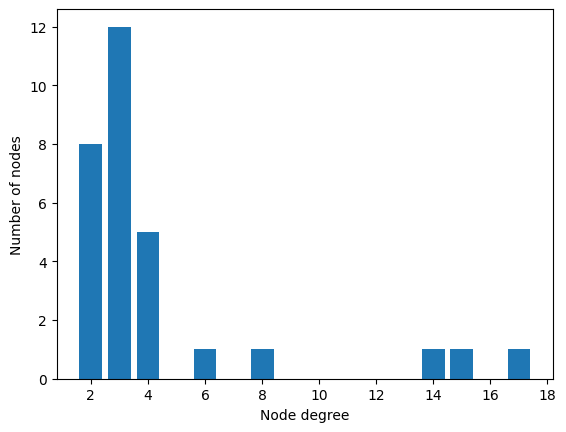

In [9]:
show_degree_distribution(G)

In [10]:
def make_graph_fast(m0, desired_num_vertices, graph_type="networkx"):
    # m0 is the initial number of connected vertices
    G = nx.Graph()
    G.add_edges_from([(i, i+1) for i in range(m0-1)])
    
    for i in range(m0, desired_num_vertices + 1):
        if graph_type == "wikipedia":
            new_edges = add_edges_wikipedia_version(G.nodes(), i, G)
        elif graph_type == "networkx":
            new_edges = add_edges_networkx_version(G.nodes(), i, G, m0)
        else:
            raise ValueError("graph_type must be 'wikipedia' or 'networkx'")
        G.add_edges_from(new_edges)
    return G


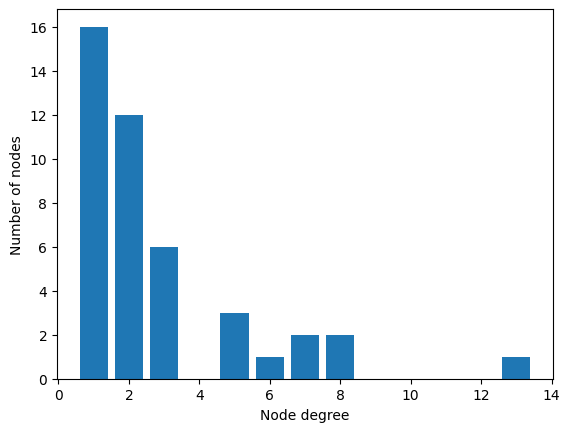

In [11]:
G = make_graph_fast(5, 70, "wikipedia")
show_degree_distribution(G)

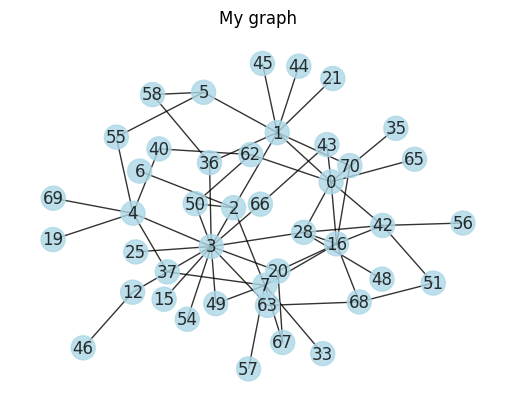

In [12]:
show_graph(G)

In [13]:
def show_progression(m0, list_num_vertices, graph_type="networkx"):
    Gs = []
    for desired_num_vertices in list_num_vertices:
        G = make_graph_fast(m0, desired_num_vertices, graph_type)
        Gs.append(G)

    fig, axes = plt.subplots(len(list_num_vertices) // 2, 2, figsize=(10,10))
    fig.suptitle(f"Degree distribution for grapsh with m0={m0}")
    # Flatten
    axes = [ax for axes_row in axes for ax in axes_row]
    for i, G in enumerate(Gs):
        ax = axes[i]
        # Show histogram
        degree_count = get_degree_count_dictionary(G)
        ax.bar(
            [float(key) for key in degree_count.keys()],
            [float(value) for value in degree_count.values()],
        )
        ax.set_xlabel("Node degree")
        ax.set_ylabel("Number of nodes")
        
        ax.set_title(f"Graph with {list_num_vertices[i]} vertices")
    plt.tight_layout()
    plt.show()
    # Save
    fig.savefig(f"progression_m0_{m0}.png")
    

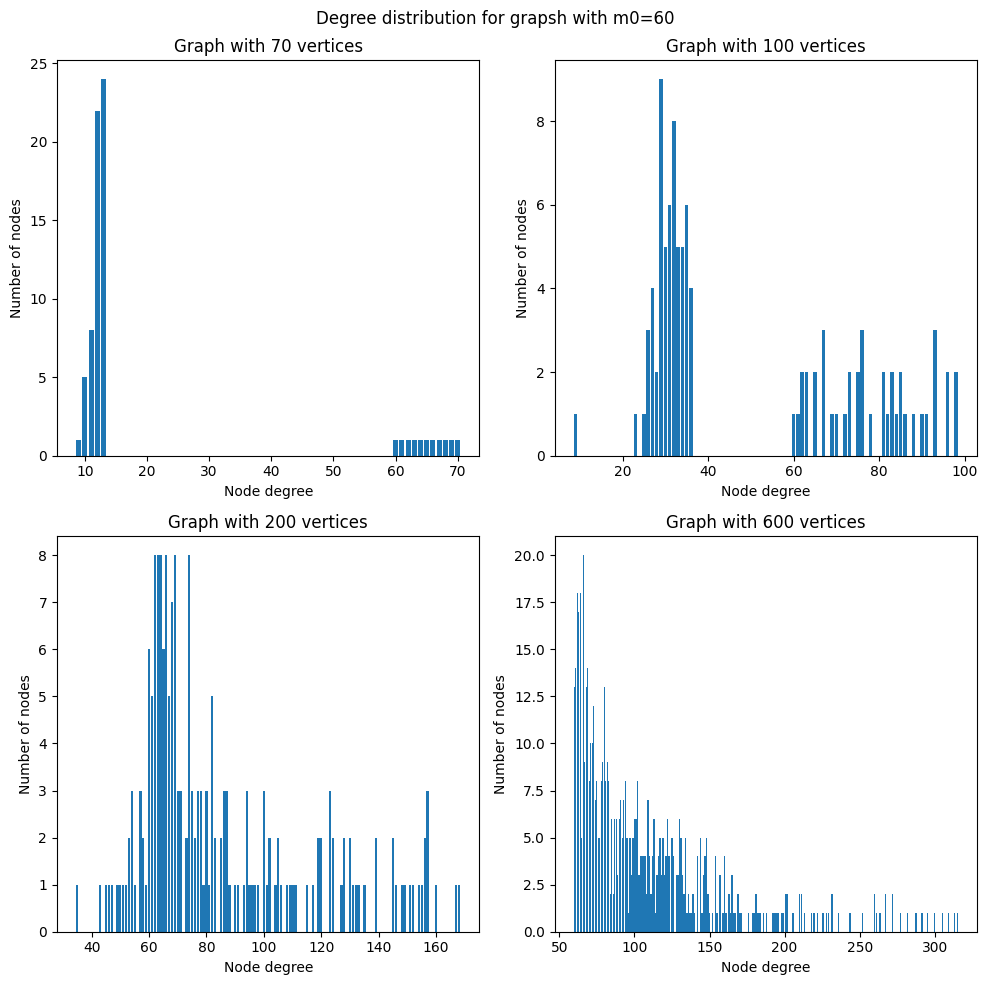

In [14]:
show_progression(60, [70, 100, 200, 600])

In [15]:
def show_log_log_progression(m0, list_num_vertices, graph_type="networkx"):
    Gs = []
    for desired_num_vertices in list_num_vertices:
        G = make_graph_fast(m0, desired_num_vertices, graph_type)
        Gs.append(G)

    fig, axes = plt.subplots(len(list_num_vertices) // 2, 2, figsize=(10, 10))
    fig.suptitle(f"Degree distribution for graphs with m0={m0}")
    # Flatten
    axes = [ax for axes_row in axes for ax in axes_row]
    for i, G in enumerate(Gs):
        ax = axes[i]
        degree_count = get_degree_count_dictionary(G)
        
        # Create a list of degrees (repeated by their counts)
        degrees = []
        for degree, count in degree_count.items():
            degrees.extend([degree] * count)
        
        bins = np.logspace(np.log10(1), np.log10(max(degree_count.keys())), 20)
        binned_counts, _ = np.histogram(degrees, bins=bins)
        
        ax.loglog(bins[:-1], binned_counts, 'o-')
        ax.set_xlabel("Node degree (log scale)")
        ax.set_ylabel("Number of nodes (log scale)")
        ax.set_title(f"Graph with {list_num_vertices[i]} vertices")
    plt.tight_layout()
    plt.show()
    fig.savefig(f"loglog_progression_m0_{m0}.png")


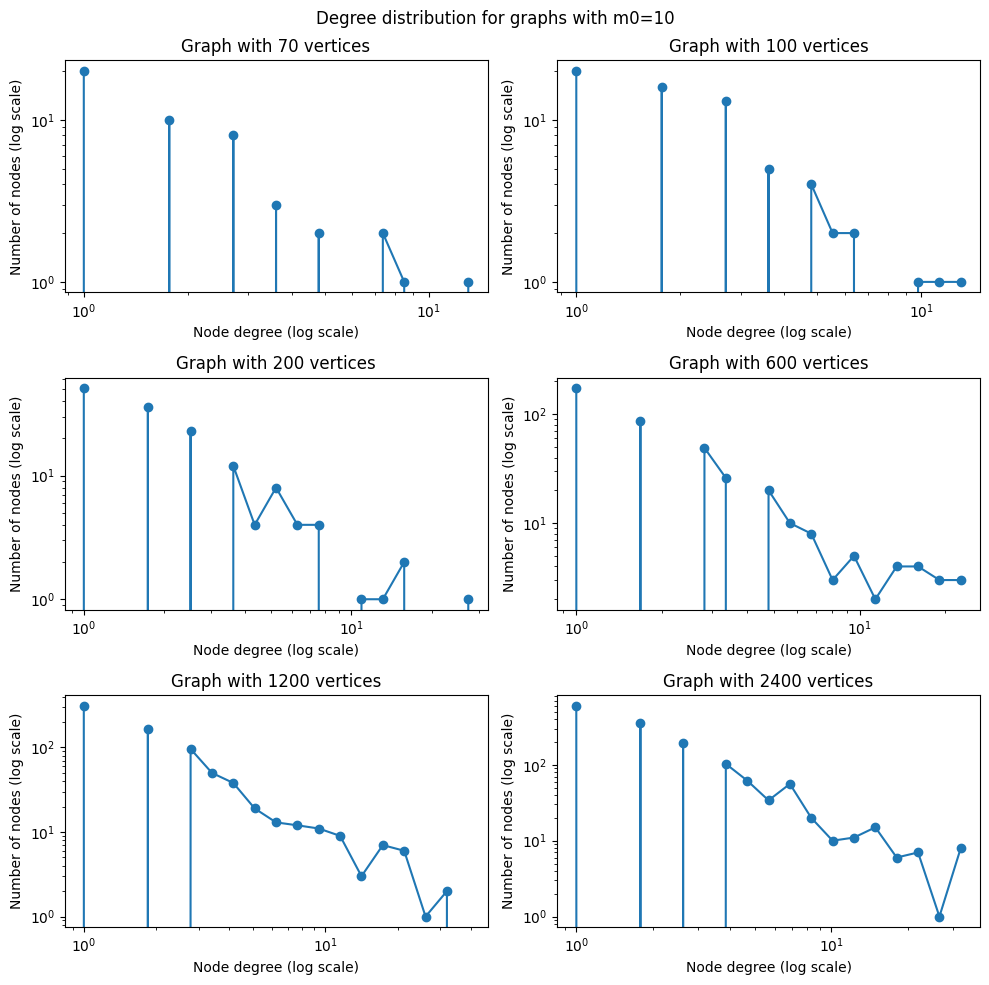

In [16]:
show_log_log_progression(10, [70, 100, 200, 600, 1200, 2400], graph_type="wikipedia")

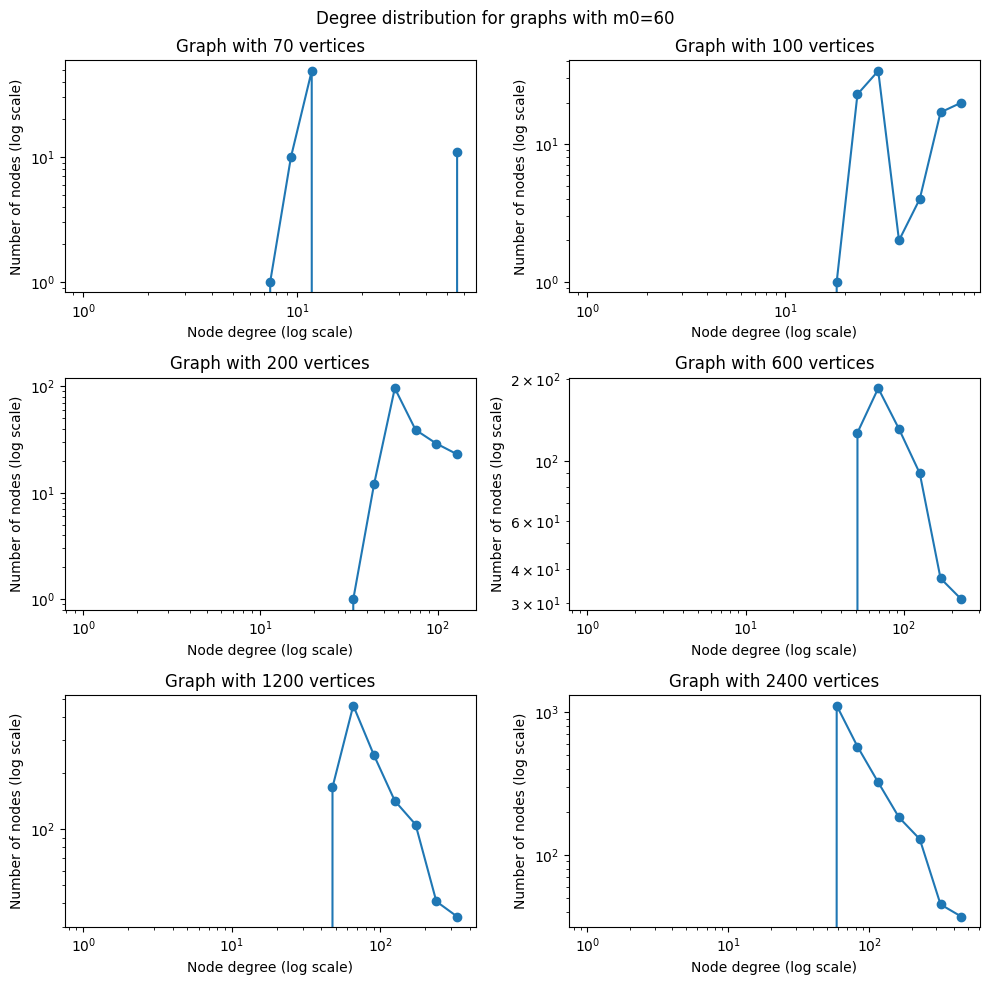

In [17]:
show_log_log_progression(60, [70, 100, 200, 600, 1200, 2400])

In [ ]:
import networkx as nx

def getG():
    G = nx.DiGraph()
    G.add_nodes_from([1,2,3,4,5])
    G.add_edges_from([(1,2),(2,3),(3,4),(4,5),(5,1)])
    pos = nx.nx_pydot.graphviz_layout(G,prog='neato')
    return G, pos

G_cycle, _ = getG()

eig_centrality = nx.eigenvector_centrality(G_cycle, max_iter=1000)
print("\nEigenvector Centrality (NetworkX):")
print("=" * 40)
for node in sorted(eig_centrality.keys()):
    print(f"Node {node}: {eig_centrality[node]:.2f}")


Eigenvector Centrality (NetworkX):
Node 1: 0.45
Node 2: 0.45
Node 3: 0.45
Node 4: 0.45
Node 5: 0.45


In [33]:
def getG():
    G = nx.DiGraph()
    G.add_nodes_from([1,2,3,4,5,6])
    G.add_edges_from([(1,2),(2,3),(3,4),(4,5),(4,1),(5,6),(6,5)])
    pos = nx.nx_pydot.graphviz_layout(G,prog='neato')
    return G, pos

G_cycle, _ = getG()

eig_centrality = nx.eigenvector_centrality(G_cycle, max_iter=100000)
print("\nEigenvector Centrality (NetworkX):")
print("=" * 40)
for node in sorted(eig_centrality.keys()):
    print(f"Node {node}: {eig_centrality[node]:.2f}")


Eigenvector Centrality (NetworkX):
Node 1: 0.00
Node 2: 0.00
Node 3: 0.00
Node 4: 0.00
Node 5: 0.71
Node 6: 0.71


In [32]:
import math

import networkx as nx
from networkx.utils import not_implemented_for

max_iter=10000
tol=1.0e-6
nstart=None
weight=None
G = G_cycle
if nstart is None:
    nstart = {v: 1 for v in G}
if all(v == 0 for v in nstart.values()):
    raise nx.NetworkXError("initial vector cannot have all zero values")
# Normalize the initial vector so that each entry is in [0, 1]. This is
# guaranteed to never have a divide-by-zero error by the previous line.
nstart_sum = sum(nstart.values())
x = {k: v / nstart_sum for k, v in nstart.items()}
nnodes = G.number_of_nodes()
# make up to max_iter iterations
for i in range(max_iter):
    xlast = x
    x = xlast.copy()  # Start with xlast times I to iterate with (A+I)
    # do the multiplication y^T = x^T A (left eigenvector)
    for n in x:
        for nbr in G[n]:
            w = G[n][nbr].get(weight, 1) if weight else 1
            x[nbr] += xlast[n] * w
    # Normalize the vector. The normalization denominator `norm`
    # should never be zero by the Perron--Frobenius
    # theorem. However, in case it is due to numerical error, we
    # assume the norm to be one instead.
    norm = math.hypot(*x.values()) or 1
    x = {k: v / norm for k, v in x.items()}
    if i % 100 == 0:
        print(x)
    # Check for convergence (in the L_1 norm).
    if sum(abs(x[n] - xlast[n]) for n in x) < nnodes * tol:
        print("Converged!")
print("No convergence")


{1: 0.3713906763541037, 2: 0.3713906763541037, 3: 0.3713906763541037, 4: 0.3713906763541037, 5: 0.5570860145311556, 6: 0.3713906763541037}
{1: 0.026897176986827715, 2: 0.026897176986827715, 3: 0.026897176986827715, 4: 0.026897176986827715, 5: 0.7127751901509343, 6: 0.6993266016575206}
{1: 0.013791791568546024, 2: 0.013791791568546024, 3: 0.013791791568546024, 4: 0.013791791568546024, 5: 0.7102772657801203, 6: 0.7033813699958474}
{1: 0.009271887132224703, 2: 0.009271887132224703, 3: 0.009271887132224703, 4: 0.009271887132224703, 5: 0.7092993656151905, 6: 0.7046634220490782}
{1: 0.00698306825600168, 2: 0.00698306825600168, 3: 0.00698306825600168, 4: 0.00698306825600168, 5: 0.7087814279841709, 6: 0.70528989385617}
{1: 0.005600483454598594, 2: 0.005600483454598594, 3: 0.005600483454598594, 4: 0.005600483454598594, 5: 0.7084611570067232, 6: 0.7056609152794239}
{1: 0.004674875423169101, 2: 0.004674875423169101, 3: 0.004674875423169101, 4: 0.004674875423169101, 5: 0.7082436266101205, 6: 0.705

In [29]:
print(x)

{1: 0.02715502074436472, 2: 0.02715502074436472, 3: 0.02715502074436472, 4: 0.02715502074436472, 5: 0.7128192945395738, 6: 0.6992417841673915}
